# Classificatore dall'encoder salvato

In [1]:
import os 
import cv2
import pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

KeyboardInterrupt: 

In [20]:
seed = 42
epochs = 500
batch_size = 16
img_size = (2048, 2048)
img_shrinked = (512,512)

## Caricamento dei dati

In [ ]:
dataset_dir = '/kaggle/input/datasets/francescospecchia/fives-duplicates'
#dataset_dir = '../FIVES'
train_dir = pathlib.Path(dataset_dir) / 'train/Original'
test_dir = pathlib.Path(dataset_dir) / 'test/Original'

In [22]:
def create_dataframe(data_dir):
    filepaths = []
    labels = []
    
    for filename in os.listdir(data_dir):
        if filename.endswith('.png'):
            filepath = os.path.join(data_dir, filename)
            
            # Extract class from filename (format: "121_G.png")
            # Assuming the class is the character after the underscore
            class_name = filename.split('_')[1].split('.')[0]  # Gets 'G' from '121_G.png'
            
            filepaths.append(filepath)
            labels.append(class_name)
    
    return pd.DataFrame({'filepath': filepaths, 'class': labels})

path_n_classes_df = create_dataframe(train_dir)

In [23]:
# Adds a black box to cover the chinese character on top left corner of an image
# And equalizes the histogram of the image



def mask_character(img):

    img[:60, :60] = 0

    #return img
    # Normalize to uint8 for OpenCV
    orig_dtype = img.dtype
    if orig_dtype != np.uint8:
        if img.max() <= 1.0:
            img_u8 = (img).astype(np.uint8)
        else:
            img_u8 = img.astype(np.uint8)
    else:
        img_u8 = img


    # Ensure 3 channels
    if img_u8.ndim == 2:
        img_u8 = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)

    # RGB -> BGR -> LAB
    bgr = cv2.cvtColor(img_u8, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L channel (uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge and convert back to RGB
    lab = cv2.merge((l, a, b))
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Return in the same value range expected by caller
    if orig_dtype == np.uint8:
        return rgb
    else:
        return (rgb.astype(np.float32))


In [24]:
train_df, val_df = train_test_split(
    path_n_classes_df, 
    test_size=0.2, 
    stratify=path_n_classes_df['class'],
    random_state=seed
)

# Create data generators
datagen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=False, #provo a settare false perché potrebbe non aiutare confondere occhio dx e sx
    preprocessing_function=mask_character,
)


datagen_val = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=mask_character
)


train_generator = datagen_train.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='class',         
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
)

validation_generator = datagen_val.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

Found 480 validated image filenames belonging to 4 classes.
Found 120 validated image filenames belonging to 4 classes.


## Modello

In [25]:
# Monitor F1 score
from sklearn.metrics import f1_score
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, x_val, y_val, average="macro"):
        super().__init__()
        self.x_val = x_val
        self.y_val = np.argmax(y_val, axis=1)  
        self.average = average
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.x_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        f1 = f1_score(
            self.y_val,
            y_pred,
            average=self.average
        )

        self.val_f1.append(f1)
        print(f" - val_f1: {f1:.4f}")

        if logs is not None:
            logs["val_f1"] = f1

In [26]:
class GradualUnfreeze(tf.keras.callbacks.Callback):

    def __init__(self, encoder, every=5):
        self.encoder = encoder
        self.every = every

    def on_epoch_begin(self, epoch, logs=None):

        if epoch % self.every == 0 and epoch > 0:

            frozen = [
                l for l in self.encoder.layers
                if not l.trainable
            ]

            if frozen:
                frozen[-1].trainable = True

                print(
                    f"Unfreezing: {frozen[-1].name}"
                )

In [27]:
img_shape = img_shrinked + (3, )
img_shape

(512, 512, 3)

autoencoder loss

In [28]:
huber = tf.keras.losses.Huber()

# combined loss: huber + ssim
def combined_loss(y_true, y_pred):

    huber_loss = huber(y_true, y_pred)

    ssim_loss = 1 - tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

    return (
        0.7 * huber_loss
        + 0.3 * ssim_loss
    )

In [ ]:
model_dir = '/kaggle/input/datasets/francescospecchia/brontes-model/brontes_seg.keras'
#model_dir = './outputs/brontes_seg.keras'
autoencoder = tf.keras.models.load_model(model_dir, custom_objects={'combined_loss':combined_loss})
autoencoder.summary()

/Users/francescospecchia/Desktop/UNI/DL/Repo/Lab/.venv/lib/python3.12/site-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512, 512,  │          0 │ add[0][0]         │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512, 512,  │          0 │ batch_normalizat

 Total params: 46,015,231 (175.53 MB)

 Trainable params: 15,334,143 (58.50 MB)

 Non-trainable params: 12,800 (50.00 KB)

 Optimizer params: 30,668,288 (116.99 MB)

In [30]:
encoder = tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.get_layer(name='multiply_4').output)
encoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512, 512,  │          0 │ add[0][0]         │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 512, 512,  │      9,248 │ leaky_re_lu_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512, 512,  │          0 │ batch_normalizat

 Total params: 11,248,350 (42.91 MB)

 Trainable params: 11,238,430 (42.87 MB)

 Non-trainable params: 9,920 (38.75 KB)

In [31]:
# i pesi tra l'encoder nell'autoncoder e quelli nell'encoder appena creato sono gli stessi?
np.allclose(
    autoencoder.layers[1].get_weights()[0],
    encoder.layers[1].get_weights()[0]
)

True

In [ ]:
def create_classifier(inputs):
    x = encoder(inputs)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(128)(x) 
    x = tf.keras.activations.leaky_relu(x) 
    x = tf.keras.layers.Dropout(0.2)(x)

    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

model = create_classifier( tf.keras.Input(shape=img_shape) )
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 32, 32, 512)    │    11,248,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyRelu)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,314,530 (43.16 MB)

 Trainable params: 11,304,610 (43.12 MB)

 Non-trainable params: 9,920 (38.75 KB)

In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

In [35]:
# Extract validation data from generator to use with F1Callback
x_val = []
y_val = []

validation_generator.reset()
for i in range(len(validation_generator)):
    images, labels = validation_generator[i]
    x_val.append(images)
    y_val.append(labels)

x_val = np.concatenate(x_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

print(f"Validation data shape: {x_val.shape}")
print(f"Validation labels shape: {y_val.shape}")

Validation data shape: (120, 512, 512, 3)
Validation labels shape: (120, 4)


In [36]:
# Calculate f1 on validation set at the end of each epoch
f1_callback = F1Callback(x_val, y_val, average="macro")

# Early stopping on validation loss
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_f1', 
    patience=20,  
    mode='max', 
    restore_best_weights=True,
    start_from_epoch=20
)

# Scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_f1',
    mode='max',
    patience=8,
    factor=0.5,
    min_lr=1e-7
)

unfreezing = GradualUnfreeze(encoder, every=3)

In [37]:

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks= [f1_callback, early_stopping, reduce_lr]
)

Epoch 1/500


AttributeError: 'Variable' object has no attribute 'ref'

In [ ]:
def plot_history(history, phase):
    plt.figure(figsize = (10,7))

    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='validation loss') 

    plt.legend()  
    #plt.xticks(range(0,n_epochs))
    #plt.semilogy()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Classification loss in Brontes phase {phase}')
    plt.grid('both', linestyle='--')
    plt.tight_layout()
    plt.savefig(f'loss_brontes_{phase}.pdf')

    plt.show()

    plt.figure(figsize = (10,7))
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='validation accuracy') 
    plt.plot(f1_callback.val_f1, label="validation f1")


    plt.legend()  
    plt.ylim([0,1]) 
    #plt.xticks(range(0,n_epochs))
    plt.yticks(np.array(range(10))/10)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy of Brontes')
    plt.grid('both', linestyle='--')
    plt.tight_layout()
    plt.savefig(f'accuracy_brontes_{phase}.pdf')

    plt.show()

In [ ]:

count = 0
for _ in encoder.layers:
    count +=1 

NUM_LAYERS = count

def find_layer_index_from_top(layer_name):
    layer = encoder.get_layer(layer_name) # no sbatti di catchare gli errori
    idx = encoder.layers.index(layer)
    return idx - NUM_LAYERS

find_layer_index_from_top('conv2d_21')


-20

In [ ]:
'''
# Phase 1: Train only the classifier
phase = 1
phase_ckpt_dir = pathlib.Path('./outputs/phase_ckpts')
phase_ckpt_dir.mkdir(parents=True, exist_ok=True)

def phase_ckpt_path(phase_number):
    return phase_ckpt_dir / f'phase_{phase_number}.weights.h5'

encoder.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(f"Number of trainable layers in encoder at phase {phase}: {len([layer for layer in encoder.layers if layer.trainable])}")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[f1_callback, reduce_lr],
)

plot_history(history, phase)
model.save_weights(phase_ckpt_path(phase))

# Phase 2: Unfreeze last conv layers
phase = 2
model.load_weights(phase_ckpt_path(phase - 1))

first_conv = find_layer_index_from_top('conv2d_21')
for layer in encoder.layers[first_conv:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-6, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(f"Number of trainable layers in encoder at phase {phase}: {len([layer for layer in encoder.layers if layer.trainable])}")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[f1_callback, reduce_lr],
)

plot_history(history, phase)
model.save_weights(phase_ckpt_path(phase))

# Phase 3: Unfreeze second to last conv layers (fourth conv)
phase = 3
model.load_weights(phase_ckpt_path(phase - 1))

first_conv = find_layer_index_from_top('conv2d_16')
for layer in encoder.layers[first_conv:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-6, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(f"Number of trainable layers in encoder at phase {phase}: {len([layer for layer in encoder.layers if layer.trainable])}")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[f1_callback, reduce_lr],
)

plot_history(history, phase)
model.save_weights(phase_ckpt_path(phase))

# Phase 4: Unfreeze third to last conv layers (third conv)
phase = 4
model.load_weights(phase_ckpt_path(phase - 1))

first_conv = find_layer_index_from_top('conv2d_11')
for layer in encoder.layers[first_conv:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(f"Number of trainable layers in encoder at phase {phase}: {len([layer for layer in encoder.layers if layer.trainable])}")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[f1_callback, reduce_lr],
)

plot_history(history, phase)
model.save_weights(phase_ckpt_path(phase))

# Phase 5: Unfreeze fourth to last conv layers (second conv)
phase = 5
model.load_weights(phase_ckpt_path(phase - 1))

first_conv = find_layer_index_from_top('conv2d_6')
for layer in encoder.layers[first_conv:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-7, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(f"Number of trainable layers in encoder at phase {phase}: {len([layer for layer in encoder.layers if layer.trainable])}")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[f1_callback, reduce_lr],
)

plot_history(history, phase)
model.save_weights(phase_ckpt_path(phase))

# Phase 6: Unfreeze first layer
phase = 6
model.load_weights(phase_ckpt_path(phase - 1))

first_conv = find_layer_index_from_top('input_layer')
for layer in encoder.layers[first_conv:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-7, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print(f"Number of trainable layers in encoder at phase {phase}: {len([layer for layer in encoder.layers if layer.trainable])}")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[f1_callback, reduce_lr],
)

plot_history(history, phase)
model.save_weights(phase_ckpt_path(phase))
'''

## Performance in test set

Found 600 validated image filenames belonging to 4 classes.
38/38 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step
Train Accuracy: 0.2483


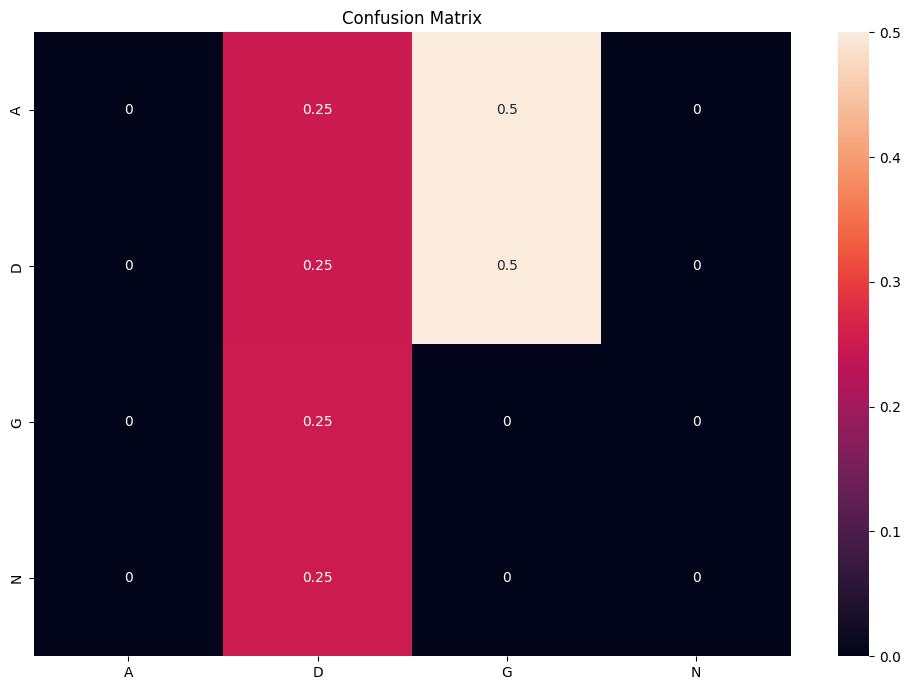

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sn

train_df = create_dataframe(train_dir)

datagen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=mask_character
)

train_generator = datagen_train.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='class',         
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

train_pred = model.predict(train_generator)
pred_train_labels = np.argmax(train_pred, axis=1)

class_labels = ['A', 'D', 'G', 'N']

# true labels
true_train_labels = np.array(train_generator.classes)

# accuracy
acc = accuracy_score(true_train_labels, pred_train_labels)

print(f"Train Accuracy: {acc:.4f}")

cm = confusion_matrix(true_train_labels, pred_train_labels, normalize='pred')
df_cm = pd.DataFrame(cm, index = [i for i in class_labels],
                  columns = [i for i in class_labels])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True)
plt.title("Confusion Matrix")
plt.tight_layout()


## Performance on test set

In [ ]:
test_df = create_dataframe(test_dir)
test_df

,filepath,class
0,../FIVES/test/Original/118_G.png,G
1,../FIVES/test/Original/168_N.png,N
2,../FIVES/test/Original/34_A.png,A
3,../FIVES/test/Original/195_N.png,N
4,../FIVES/test/Original/91_D.png,D
...,...,...
195,../FIVES/test/Original/114_G.png,G
196,../FIVES/test/Original/164_N.png,N
197,../FIVES/test/Original/60_D.png,D
198,../FIVES/test/Original/199_N.png,N


In [ ]:
datagen_test = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=mask_character
)

test_generator = datagen_test.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='class',
    target_size=img_shrinked,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 200 validated image filenames belonging to 4 classes.


In [ ]:
test_pred = model.predict(test_generator)
print(test_pred.shape)
pred_labels = np.argmax(test_pred, axis = 1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
(200, 4)


Test Accuracy: 0.2500


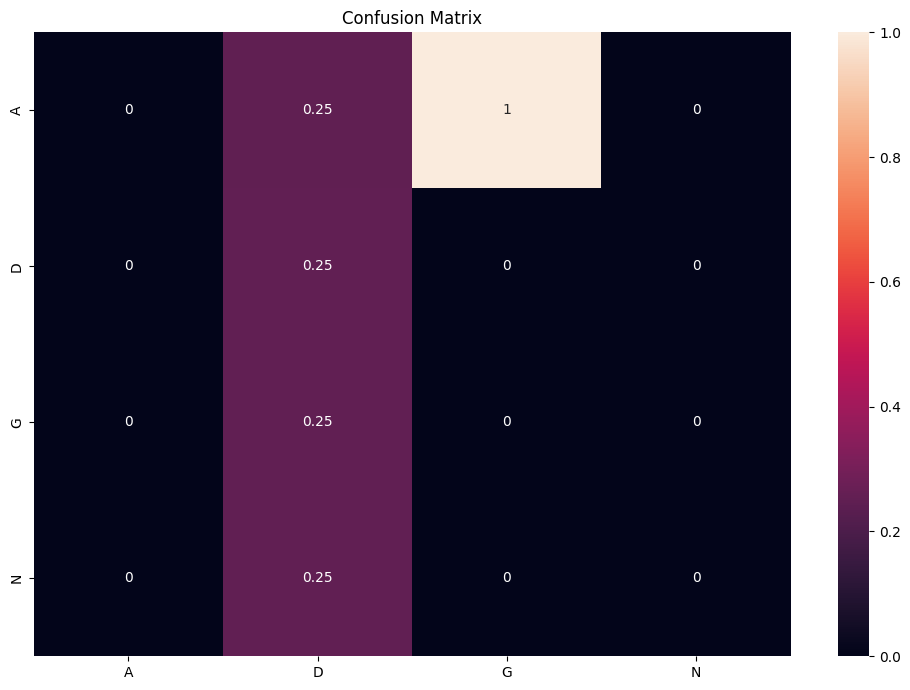

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sn

# true labels
true_labels = np.array(test_generator.classes)
class_labels = ['A', 'D', 'G', 'N']

#print(true_labels)
#print(pred_labels)
# accuracy
acc = accuracy_score(true_labels, pred_labels)

print(f"Test Accuracy: {acc:.4f}")

cm = confusion_matrix(true_labels, pred_labels, normalize='pred')
df_cm = pd.DataFrame(cm, index = [i for i in class_labels],
                  columns = [i for i in class_labels])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True)
plt.title("Confusion Matrix")
plt.tight_layout()


In [ ]:
results = model.evaluate(test_generator)
print("test loss, test acc, test auc:", results)
results_train = model.evaluate(train_generator)
print("train loss, train acc, train auc:", results_train)

13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.2500 - auc_2: 0.5185 - loss: 1.3112
test loss, test acc: [1.3111927509307861, 0.25, 0.5185499787330627]


## Gradcam

2026-06-21 11:31:33.837076: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


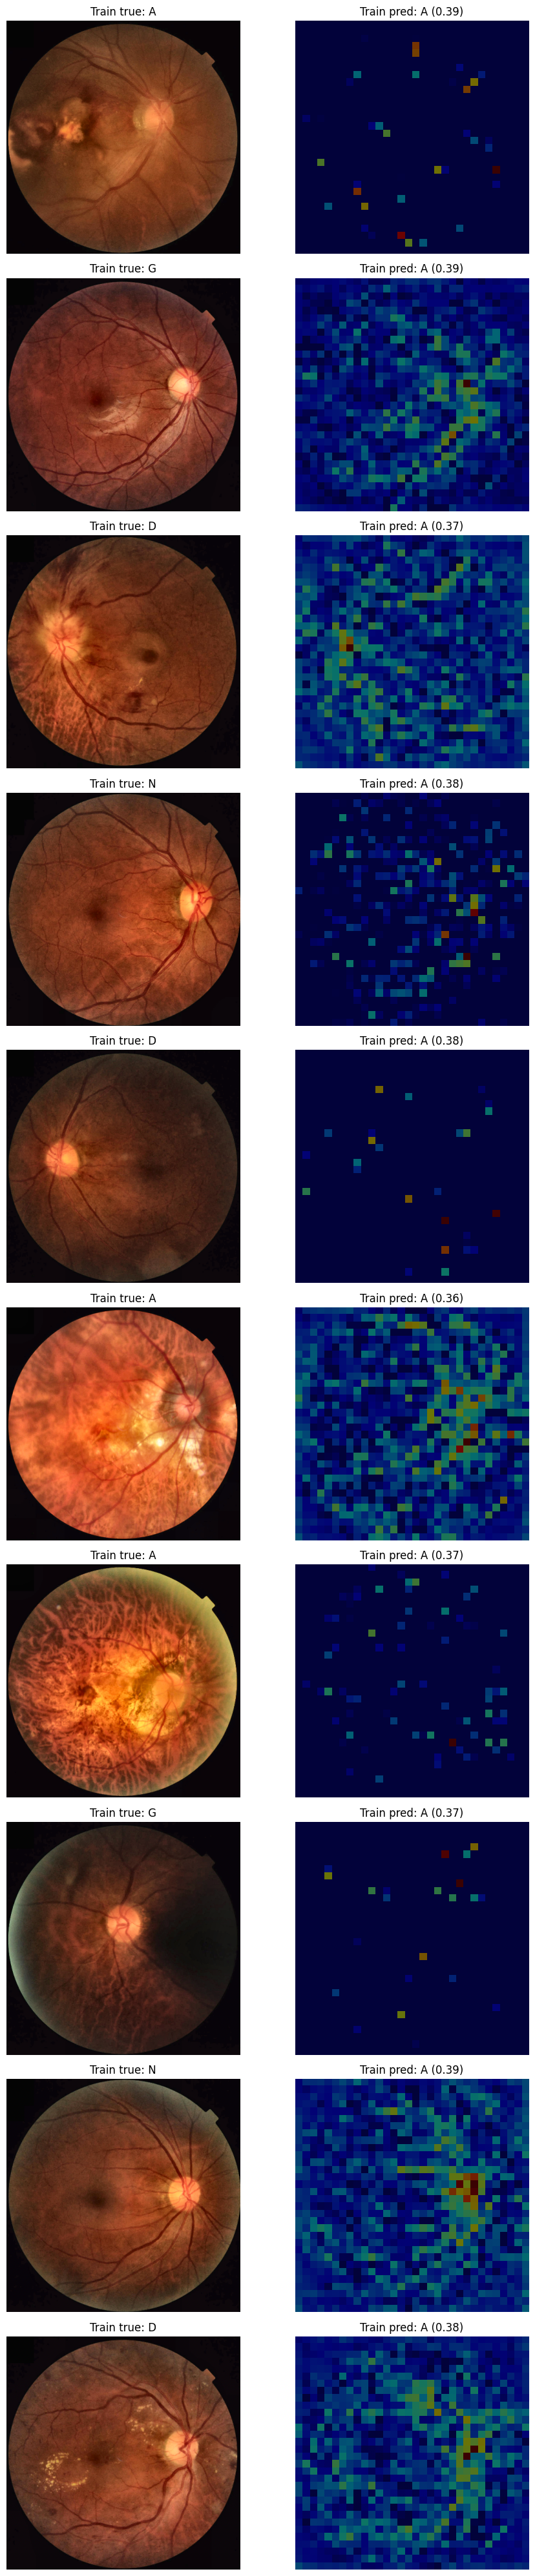

In [ ]:
class_labels = ['A', 'D', 'G', 'N']

grad_inputs = tf.keras.Input(shape=img_shape)
feature_maps = encoder(grad_inputs)
x = model.layers[-3](feature_maps)
x = model.layers[-2](x)
grad_predictions = model.layers[-1](x)

grad_model = tf.keras.Model(
    inputs=grad_inputs,
    outputs=[feature_maps, grad_predictions]
)

def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        pred_index = int(pred_index)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, feature_maps)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(feature_maps * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
    return heatmap.numpy()

def load_image_for_gradcam(filepath):
    image = tf.keras.utils.load_img(filepath, target_size=img_shrinked)
    image_array = tf.keras.utils.img_to_array(image)
    image_array = mask_character(image_array)
    image_array = image_array / 255.0
    return image_array

def get_eval_dataframe(split='test'):
    if split == 'test':
        return test_df
    if split == 'train':
        return create_dataframe(train_dir)
    raise ValueError("split must be either 'test' or 'train'")

def plot_random_gradcams(split='test', n_samples=6, seed=42):
    eval_df = get_eval_dataframe(split)
    rng = np.random.default_rng(seed)
    n_samples = min(n_samples, len(eval_df))
    sample_indices = rng.choice(len(eval_df), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(sample_indices):
        filepath = eval_df.iloc[idx]['filepath']
        true_label = eval_df.iloc[idx]['class']

        image_array = load_image_for_gradcam(filepath)
        batch = np.expand_dims(image_array, axis=0)

        predictions = model.predict(batch, verbose=0)[0]
        pred_index = int(np.argmax(predictions))
        heatmap = make_gradcam_heatmap(batch, grad_model, pred_index=pred_index)

        axes[row, 0].imshow(image_array)
        axes[row, 0].set_title(f'{split.title()} true: {true_label}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(image_array)
        axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[row, 1].set_title(
            f'{split.title()} pred: {class_labels[pred_index]} ({predictions[pred_index]:.2f})'
        )
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

plot_random_gradcams(split='test', n_samples=10, seed=14)
# To visualize training samples instead, run:
plot_random_gradcams(split='train', n_samples=10, seed=seed)

In [ ]:
model.save(f'brontes-class_{acc:.4f}.keras')